# 01 - Análise Exploratória dos Dados

Este notebook analisa a base de perdas de materiais utilizada no projeto.

A análise tem três focos principais:

1. entender a distribuição do `indice_perda_real`, que será o alvo do modelo;
2. verificar como a perda varia conforme serviço, material e contexto de execução;
3. separar as colunas que podem entrar no modelo daquelas que devem permanecer apenas como informação auxiliar.

Nenhuma transformação definitiva será aplicada aqui. O objetivo é fechar as decisões que serão executadas no notebook de modelagem.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

project_path = Path("..")
raw_data_path = project_path / "data" / "raw"
df = pd.read_csv(raw_data_path / "perda_material.csv")

## 1. Visão geral da base

Antes de analisar relações entre variáveis, é importante fazer uma checagem inicial da estrutura do dataset. Aqui são verificados o formato da base, tipos das colunas, possíveis valores ausentes, duplicidades e estatísticas descritivas das variáveis numéricas.


In [2]:
# Verificando o formato geral da base: linhas e colunas
display(df.shape)

# Conferindo as primeiras linhas para entender a estrutura dos registros
display(df.head())

# Verificando tipos de dados e quantidade de valores preenchidos por coluna
df.info()

(5000, 32)

,registro_id,obra_id,data_registro,requisicao_id,empreiteiro_id,fornecedor_id,tipo_obra,fase_obra,ambiente,servico,...,pressao_prazo,qtd_frentes_simultaneas,quantidade_real_consumida,quantidade_sobra_reaproveitavel,quantidade_perdida_nao_reaproveitavel,houve_retrabalho_real,motivo_principal_perda,indice_perda_real,custo_perda_real,risco_perda_real
0,REG_00001,OBRA_020,2025-07-12,REQ_01849,EMP_014,FORN_040,industrial,fechamento,interno,impermeabilizacao,...,media,2,2297.46,67.78,216.62,0,recorte_ajuste,0.1413,8699.36,alto
1,REG_00002,OBRA_003,2025-02-09,REQ_01673,EMP_029,FORN_040,comercial,acabamento,interno,esquadrias_madeira,...,media,1,2651.13,104.37,214.92,1,retrabalho,0.1369,202158.16,alto
2,REG_00003,OBRA_018,2025-04-23,REQ_02051,EMP_035,FORN_005,industrial,fechamento,interno,vedacao_alvenaria,...,media,5,1809.75,53.78,157.03,0,consumo_acima_previsto,0.1318,471.10,alto
3,REG_00004,OBRA_014,2025-07-31,REQ_00070,EMP_033,FORN_008,industrial,estrutura,externo,estrutura_concreto,...,media,3,2184.37,49.40,225.61,0,consumo_acima_previsto,0.1440,15731.87,alto
4,REG_00005,OBRA_013,2025-02-21,REQ_01355,EMP_001,FORN_046,comercial,estrutura,externo,estrutura_concreto,...,alta,4,2214.72,46.52,119.08,0,recorte_ajuste,0.0808,37108.88,medio


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   registro_id                            5000 non-null   object 
 1   obra_id                                5000 non-null   object 
 2   data_registro                          5000 non-null   object 
 3   requisicao_id                          5000 non-null   object 
 4   empreiteiro_id                         5000 non-null   object 
 5   fornecedor_id                          5000 non-null   object 
 6   tipo_obra                              5000 non-null   object 
 7   fase_obra                              5000 non-null   object 
 8   ambiente                               5000 non-null   object 
 9   servico                                5000 non-null   object 
 10  complexidade_execucao                  5000 non-null   object 
 11  nece

In [3]:
# Verificando se existem valores ausentes em alguma coluna
display(df.isna().sum())

# Verificando se existem linhas duplicadas no dataset
display(df.duplicated().sum())

,0
registro_id,0
obra_id,0
data_registro,0
requisicao_id,0
empreiteiro_id,0
fornecedor_id,0
tipo_obra,0
fase_obra,0
ambiente,0
servico,0


np.int64(0)

In [4]:
# Estatísticas descritivas das variáveis numéricas
df.describe()

,material_fragil,material_modular,custo_unitario,quantidade_teorica,indice_perda_orcado,quantidade_orcada,compra_emergencial,qtd_frentes_simultaneas,quantidade_real_consumida,quantidade_sobra_reaproveitavel,quantidade_perdida_nao_reaproveitavel,houve_retrabalho_real,indice_perda_real,custo_perda_real
count,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.265600,0.5418,87.405388,1293.796072,0.056390,1366.758888,0.248400,4.0280,1429.771230,34.253066,101.722018,0.093200,0.105197,7781.708692
std,0.441696,0.4983,167.175430,716.137391,0.021691,756.927137,0.432128,1.9966,792.223885,30.050006,69.834720,0.290742,0.033632,18104.181605
min,0.000000,0.0000,0.200000,20.180000,0.010000,20.880000,0.000000,1.0000,21.760000,0.000000,0.790000,0.000000,0.005000,3.470000
25%,0.000000,0.0000,7.195000,678.047500,0.040800,723.277500,0.000000,2.0000,748.430000,11.647500,46.267500,0.000000,0.082000,504.855000
50%,0.000000,1.0000,26.805000,1302.675000,0.055100,1376.645000,0.000000,4.0000,1443.180000,27.010000,89.990000,0.000000,0.103750,1726.850000
75%,1.000000,1.0000,76.155000,1914.335000,0.070725,2031.530000,0.000000,6.0000,2124.030000,49.012500,145.305000,0.000000,0.126525,6720.407500
max,1.000000,1.0000,1187.910000,2499.770000,0.132600,2757.150000,1.000000,7.0000,2961.480000,201.340000,475.460000,1.000000,0.261400,260694.270000


## 2. Análise da variável-alvo

A variável `indice_perda_real` será o alvo do modelo de regressão. Por isso, antes de analisar as demais variáveis, é importante entender sua distribuição, sua faixa de valores e a presença de valores extremos.

In [5]:
# Estatísticas descritivas da variável-alvo
df["indice_perda_real"].describe()

,indice_perda_real
count,5000.000000
mean,0.105197
std,0.033632
min,0.005000
25%,0.082000
50%,0.103750
75%,0.126525
max,0.261400


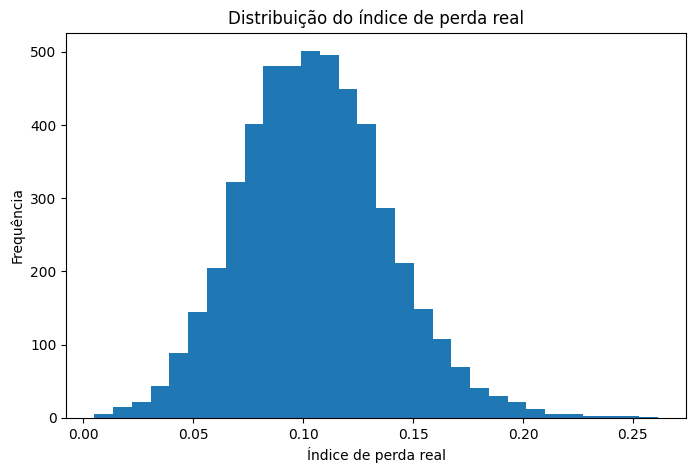

In [6]:
# Distribuição do índice de perda real
plt.figure(figsize = (8, 5))
plt.hist(df["indice_perda_real"], bins = 30)
plt.title("Distribuição do índice de perda real")
plt.xlabel("Índice de perda real")
plt.ylabel("Frequência")
plt.show()

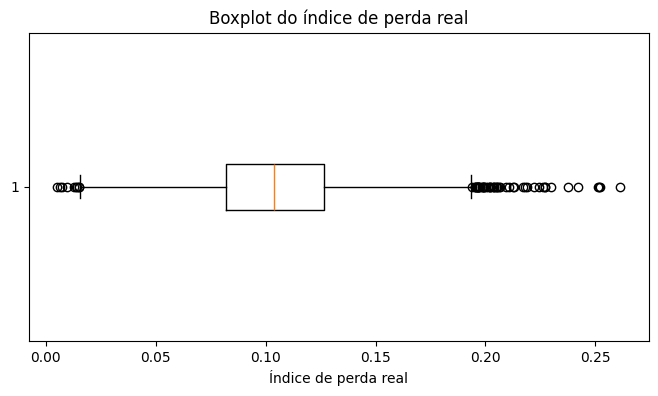

In [7]:
# Boxplot do índice de perda real
plt.figure(figsize = (8, 4))
plt.boxplot(df["indice_perda_real"], vert = False)
plt.title("Boxplot do índice de perda real")
plt.xlabel("Índice de perda real")
plt.show()

In [8]:
# Distribuição da classificação auxiliar de risco
df["risco_perda_real"].value_counts(normalize = True)

,proportion
risco_perda_real,
medio,0.6428
alto,0.2164
baixo,0.1408


A distribuição do `indice_perda_real` indica a faixa de perdas observada na base. A presença de alguns valores mais altos é coerente com fatores como complexidade, necessidade de corte/ajuste, pressão de prazo e retrabalho real.

A classificação `risco_perda_real` será mantida apenas como variável auxiliar de leitura. Como ela é derivada diretamente do alvo, não será utilizada como entrada na modelagem.

## 3. Análise por serviço e material

Depois de olhar a distribuição geral do alvo, a próxima etapa é entender como o índice de perda varia entre diferentes serviços e materiais.

Essa análise ajuda a verificar se a base está refletindo uma lógica plausível de obra: serviços e materiais sujeitos a maior corte, ajuste, quebra, consumo variável ou retrabalho tendem a apresentar perdas médias diferentes.

In [9]:
# Quantidade de registros por tipo de serviço
df["servico"].value_counts()

,count
servico,
estrutura_metalica,342
forro,341
esquadrias_madeira,330
pintura,327
instalacoes_incendio,325
fundacao,318
esquadrias_metal_vidro,318
instalacoes_eletricas,317
estrutura_concreto,314


In [10]:
# Índice médio de perda real por serviço
perda_por_servico = (
    df.groupby("servico")["indice_perda_real"]
    .mean()
    .sort_values(ascending = False)
)
perda_por_servico

,indice_perda_real
servico,
revestimento_piso_parede,0.127755
vedacao_alvenaria,0.125624
impermeabilizacao,0.118779
forro,0.116120
fachada_fechamento_externo,0.114741
vedacao_drywall,0.110872
cobertura,0.108986
instalacoes_hidrossanitarias,0.107500
pintura,0.107175


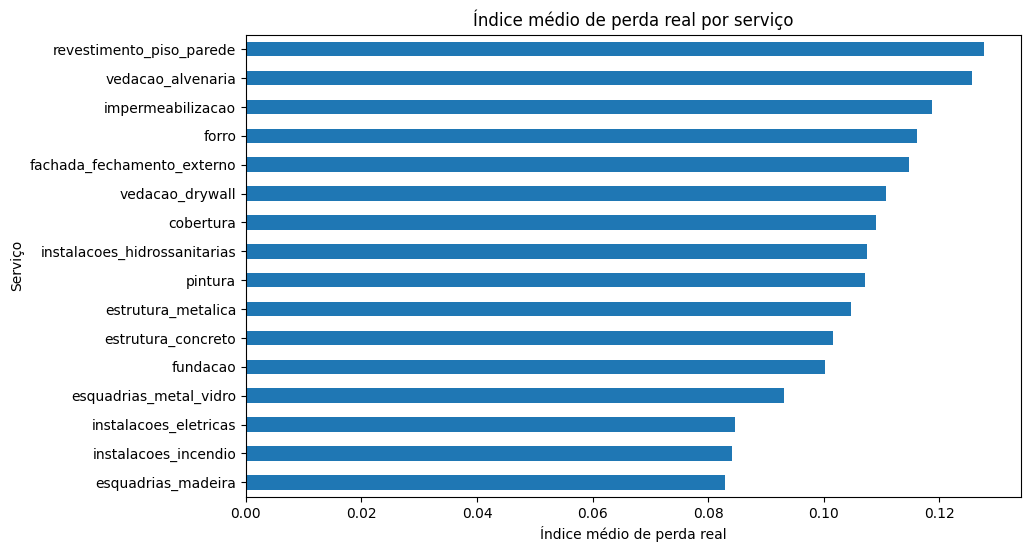

In [11]:
# Visualização da perda média por serviço
plt.figure(figsize = (10, 6))
perda_por_servico.sort_values().plot(kind = "barh")
plt.title("Índice médio de perda real por serviço")
plt.xlabel("Índice médio de perda real")
plt.ylabel("Serviço")
plt.show()

In [12]:
# Materiais com maior índice médio de perda real
perda_por_material = (
    df.groupby("material")["indice_perda_real"]
    .mean()
    .sort_values(ascending = False)
)
perda_por_material.head(15)

,indice_perda_real
material,
manta_asfaltica,0.154593
acm,0.146327
porcelanato,0.141543
argamassa_assentamento,0.135922
argamassa_colante,0.134453
placa_gesso_60x60,0.132357
piso_ceramico,0.127689
forma_madeira,0.123665
bloco_ceramico,0.122876


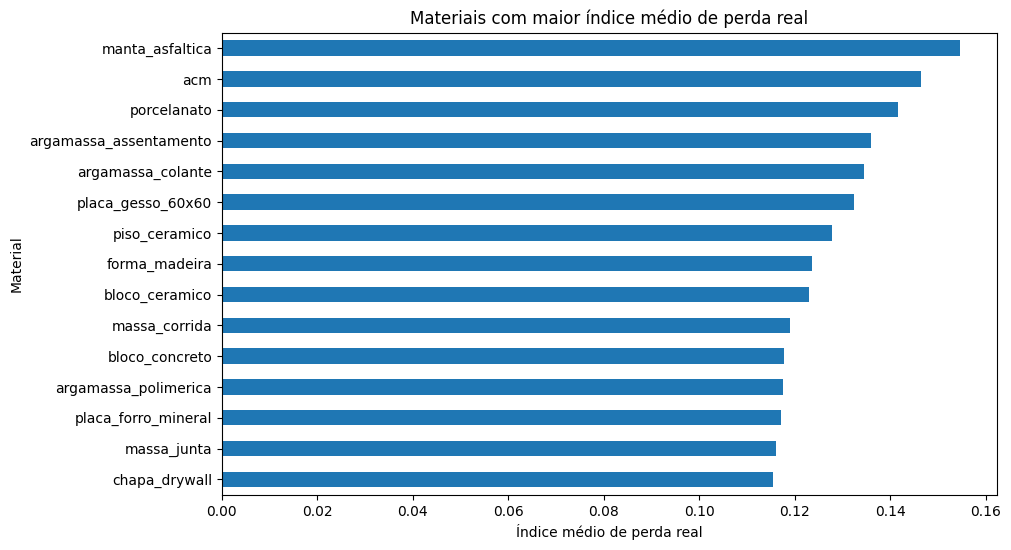

In [13]:
# Visualização dos materiais com maior perda média
plt.figure(figsize = (10, 6))
perda_por_material.head(15).sort_values().plot(kind = "barh")
plt.title("Materiais com maior índice médio de perda real")
plt.xlabel("Índice médio de perda real")
plt.ylabel("Material")
plt.show()

In [14]:
# Comparação da perda média entre materiais principais, acessórios e consumíveis
df.groupby("tipo_item_material")["indice_perda_real"].mean().sort_values(ascending = False)

,indice_perda_real
tipo_item_material,
consumivel,0.107675
principal,0.105682
acessorio,0.102542


O índice médio de perda varia de forma relevante entre serviços e materiais. Essa diferença é coerente com a lógica do problema, já que cada serviço combina materiais, níveis de corte/ajuste, complexidade e condições operacionais diferentes.

A análise por material também mostra que a perda não depende apenas do serviço, mas do comportamento do item utilizado. Por isso, `servico`, `material` e `tipo_item_material` serão mantidos como variáveis consideradas na modelagem.

## 4. Contexto operacional e características técnicas

Além do serviço e do material, algumas condições de execução podem influenciar o índice de perda. Nesta seção, analiso variáveis como complexidade, necessidade de corte/ajuste, pressão de prazo, quantidade de frentes simultâneas, fragilidade e modularidade do material.

Essas variáveis são importantes porque representam informações que poderiam ser conhecidas antes da execução e, portanto, podem ser usadas na modelagem.

In [15]:
# Perda média por nível de complexidade da execução
df.groupby("complexidade_execucao")["indice_perda_real"].mean().sort_values(ascending = False)

,indice_perda_real
complexidade_execucao,
alta,0.117781
media,0.104028
baixa,0.094854


In [16]:
# Perda média por necessidade de corte e ajuste
df.groupby("necessidade_corte_ajuste")["indice_perda_real"].mean().sort_values(ascending = False)

,indice_perda_real
necessidade_corte_ajuste,
alta,0.116694
media,0.100256
baixa,0.087621


In [17]:
# Perda média por pressão de prazo
df.groupby("pressao_prazo")["indice_perda_real"].mean().sort_values(ascending = False)

,indice_perda_real
pressao_prazo,
alta,0.116051
media,0.103728
baixa,0.094880


In [18]:
# Perda média por quantidade de frentes simultâneas
perda_por_frentes = (
    df.groupby("qtd_frentes_simultaneas")["indice_perda_real"]
    .mean()
)
perda_por_frentes

,indice_perda_real
qtd_frentes_simultaneas,
1,0.098217
2,0.101186
3,0.097026
4,0.102963
5,0.107334
6,0.111543
7,0.117486


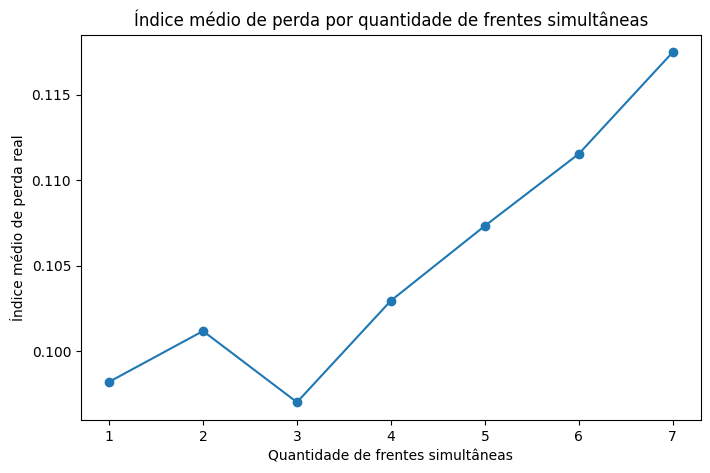

In [19]:
# Visualização da tendência entre frentes simultâneas e perda média
plt.figure(figsize = (8, 5))
perda_por_frentes.plot(kind = "line", marker = "o")
plt.title("Índice médio de perda por quantidade de frentes simultâneas")
plt.xlabel("Quantidade de frentes simultâneas")
plt.ylabel("Índice médio de perda real")
plt.show()

In [20]:
# Comparação entre materiais frágeis e não frágeis
df.groupby("material_fragil")["indice_perda_real"].mean()

,indice_perda_real
material_fragil,
0,0.104854
1,0.106148


In [21]:
# Comparação entre materiais modulares e não modulares
df.groupby("material_modular")["indice_perda_real"].mean()

,indice_perda_real
material_modular,
0,0.099551
1,0.109973


In [22]:
# Relação entre pressão de prazo e compra emergencial
# A compra emergencial fica na base bruta, mas tende a ser excluída da modelagem por possível sobreposição com pressao_prazo.
pd.crosstab(
    df["pressao_prazo"],
    df["compra_emergencial"],
    normalize = "index"
)

compra_emergencial,0,1
pressao_prazo,,
alta,0.542272,0.457728
baixa,0.922535,0.077465
media,0.796196,0.203804


As variáveis de contexto operacional apresentam comportamento coerente com a lógica do problema. Complexidade de execução, necessidade de corte/ajuste e pressão de prazo mostram diferenças no índice médio de perda, o que reforça sua permanência como variáveis de entrada do modelo.

A quantidade de frentes simultâneas também será mantida, pois representa uma condição operacional disponível antes da execução e pode indicar maior dificuldade de controle.

A variável `compra_emergencial` foi analisada por sua relação com `pressao_prazo`. Apesar de estar presente na base, ela não será usada como feature, para evitar redundância e porque representa mais uma condição de suprimentos do que uma característica direta da execução.

## 5. Perda orçada x perda real

A coluna `indice_perda_orcado` representa o percentual de perda considerado no planejamento do material. Já `indice_perda_real` representa a perda observada após a execução.

Comparar essas duas variáveis ajuda a entender o quanto a perda real se distancia da estimativa inicial. Essa diferença é uma das principais justificativas do projeto: usar informações de serviço, material e contexto operacional para prever um índice de perda mais ajustado à condição real da obra.

In [23]:
# Comparação direta entre o índice previsto no orçamento e o índice real observado
df[["indice_perda_orcado", "indice_perda_real"]].describe()

,indice_perda_orcado,indice_perda_real
count,5000.000000,5000.000000
mean,0.056390,0.105197
std,0.021691,0.033632
min,0.010000,0.005000
25%,0.040800,0.082000
50%,0.055100,0.103750
75%,0.070725,0.126525
max,0.132600,0.261400


In [24]:
df["diferenca_perda_real_orcada"] = df["indice_perda_real"] - df["indice_perda_orcado"]
df["diferenca_perda_real_orcada"].describe()
# Diferença positiva indica que a perda real ficou acima da perda orçada e negativa indica que a perda real ficou abaixo da perda orçada

,diferenca_perda_real_orcada
count,5000.000000
mean,0.048807
std,0.031009
min,-0.046900
25%,0.028000
50%,0.047400
75%,0.067925
max,0.197100


In [25]:
# Percentual de registros em que a perda real superou a perda prevista no orçamento
print(f"{(df["diferenca_perda_real_orcada"] > 0).mean() * 100:2.2f}%")

94.98%


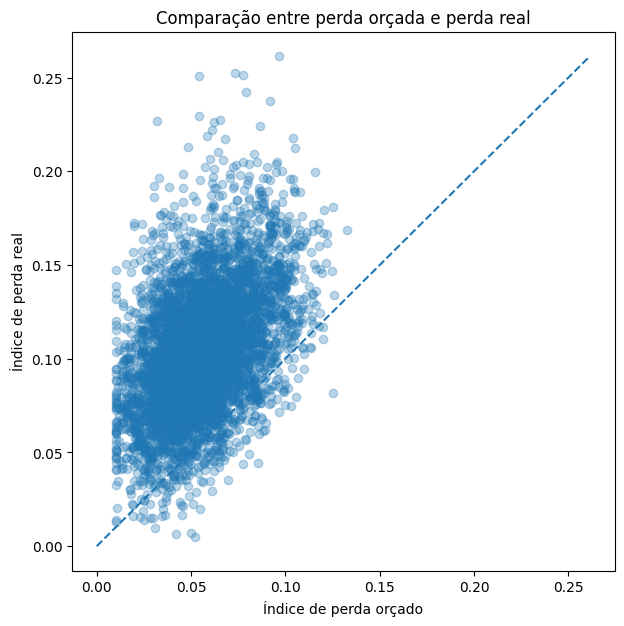

In [26]:
# Comparação visual entre perda orçada e perda real
plt.figure(figsize=(7, 7))
plt.scatter(
    df["indice_perda_orcado"],
    df["indice_perda_real"],
    alpha=0.3
)
limite_max = max(
    df["indice_perda_orcado"].max(),
    df["indice_perda_real"].max()
)
plt.plot([0, limite_max], [0, limite_max], linestyle = "--")
plt.title("Comparação entre perda orçada e perda real")
plt.xlabel("Índice de perda orçado")
plt.ylabel("Índice de perda real")
plt.show()
# Pontos acima da linha tracejada indicam perda real maior que a orçada

In [27]:
# Diferença média entre perda real e orçada por serviço
diferenca_por_servico = (
    df.groupby("servico")["diferenca_perda_real_orcada"]
    .mean()
    .sort_values(ascending = False)
)
diferenca_por_servico

,diferenca_perda_real_orcada
servico,
cobertura,0.051542
estrutura_concreto,0.050261
forro,0.050135
fundacao,0.049998
revestimento_piso_parede,0.049872
esquadrias_madeira,0.049799
instalacoes_hidrossanitarias,0.049366
estrutura_metalica,0.049215
vedacao_alvenaria,0.048840


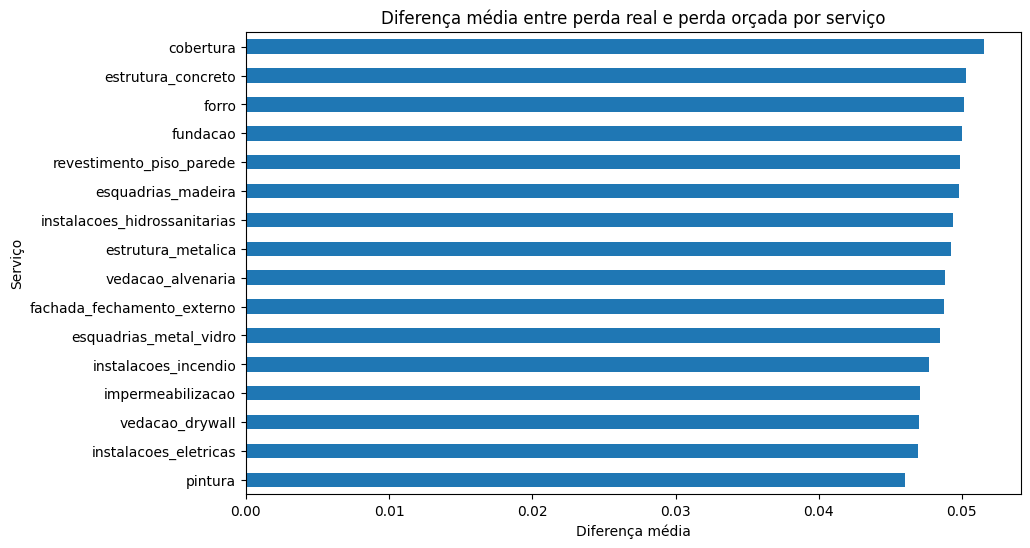

In [28]:
# Visualização da diferença média por serviço
plt.figure(figsize = (10, 6))
diferenca_por_servico.sort_values().plot(kind = "barh")
plt.title("Diferença média entre perda real e perda orçada por serviço")
plt.xlabel("Diferença média")
plt.ylabel("Serviço")
plt.show()

A perda real apresenta desvio relevante em relação à perda orçada. Isso reforça a proposta do projeto: em vez de usar apenas um percentual de referência, o modelo buscará estimar a perda considerando características do serviço, do material e do contexto operacional.

A coluna `indice_perda_orcado` será mantida como variável de entrada, pois representa uma referência disponível antes da execução. Já `diferenca_perda_real_orcada` foi criada apenas para análise exploratória.

## 6. Colunas pós-execução e vazamento de dados

A base bruta contém algumas colunas que só seriam conhecidas depois da execução do serviço. Elas são úteis para entender o histórico de perdas, mas não podem ser usadas como entrada do modelo.

O modelo deve prever o `indice_perda_real` com informações disponíveis antes ou no momento da decisão de compra/planejamento. Usar dados como consumo real, retrabalho real ou motivo da perda faria o modelo acessar informações do futuro.

In [29]:
# Separação de colunas que representam informações conhecidas apenas após a execução
colunas_pos_execucao = [
    "quantidade_real_consumida",
    "quantidade_sobra_reaproveitavel",
    "quantidade_perdida_nao_reaproveitavel",
    "houve_retrabalho_real",
    "motivo_principal_perda",
    "custo_perda_real",
    "risco_perda_real"
]
df[colunas_pos_execucao].head()

,quantidade_real_consumida,quantidade_sobra_reaproveitavel,quantidade_perdida_nao_reaproveitavel,houve_retrabalho_real,motivo_principal_perda,custo_perda_real,risco_perda_real
0,2297.46,67.78,216.62,0,recorte_ajuste,8699.36,alto
1,2651.13,104.37,214.92,1,retrabalho,202158.16,alto
2,1809.75,53.78,157.03,0,consumo_acima_previsto,471.10,alto
3,2184.37,49.40,225.61,0,consumo_acima_previsto,15731.87,alto
4,2214.72,46.52,119.08,0,recorte_ajuste,37108.88,medio


In [30]:
# Comparando a perda média entre registros com e sem retrabalho real
df.groupby("houve_retrabalho_real")["indice_perda_real"].mean()

,indice_perda_real
houve_retrabalho_real,
0,0.102105
1,0.135284


In [31]:
# Perda média associada a cada motivo principal
df.groupby("motivo_principal_perda")["indice_perda_real"].mean().sort_values(ascending = False)

,indice_perda_real
motivo_principal_perda,
retrabalho,0.135284
perda_nao_identificada,0.105002
sobra_nao_reaproveitavel,0.102979
consumo_acima_previsto,0.102736
erro_execucao,0.102492
recorte_ajuste,0.101774
quebra_dano,0.101102
alteracao_projeto,0.099571


As colunas pós-execução ajudam a explicar o comportamento histórico das perdas, especialmente variáveis como `houve_retrabalho_real` e `motivo_principal_perda`.

Mesmo quando apresentam relação clara com o `indice_perda_real`, essas colunas não serão usadas na modelagem, pois só estariam disponíveis após a execução. Mantê-las como entrada geraria vazamento de dados e faria o modelo parecer melhor do que seria em uma aplicação real.

## 7. Definição das variáveis

A partir da análise exploratória, as colunas foram separadas entre variáveis que podem ser usadas na modelagem e colunas que devem permanecer apenas na base bruta.

O modelo usará somente informações disponíveis antes da execução do serviço ou no momento da previsão. Por isso, colunas de identificação, variáveis pós-execução e campos derivados diretamente da perda real serão removidos.


In [32]:
# Colunas de identificação: úteis para rastreabilidade, mas não para previsão
colunas_identificacao = [
    "registro_id",
    "obra_id",
    "data_registro",
    "requisicao_id",
    "empreiteiro_id",
    "fornecedor_id"
]
# Colunas conhecidas apenas após a execução do serviço
colunas_pos_execucao = [
    "quantidade_real_consumida",
    "quantidade_sobra_reaproveitavel",
    "quantidade_perdida_nao_reaproveitavel",
    "houve_retrabalho_real",
    "motivo_principal_perda"
]
# Colunas calculadas, auxiliares ou derivadas do alvo
colunas_calculadas_ou_auxiliares = [
    "quantidade_orcada",
    "custo_perda_real",
    "risco_perda_real",
    "diferenca_perda_real_orcada"
]
# Outras colunas removidas por decisão de modelagem
colunas_removidas = [
    "compra_emergencial",
    "unidade_medida"
]

In [33]:
# Colunas excluídas do modelo
colunas_excluidas = (
    colunas_identificacao
    + colunas_pos_execucao
    + colunas_calculadas_ou_auxiliares
    + colunas_removidas
  )
alvo = "indice_perda_real"

In [34]:
# Features que serão usadas no modelo
features = [
    coluna for coluna in df.columns
    if coluna not in colunas_excluidas + [alvo]
  ]
print("Quantidade de features:", len(features))
features

Quantidade de features: 15


['tipo_obra',
 'fase_obra',
 'ambiente',
 'servico',
 'complexidade_execucao',
 'necessidade_corte_ajuste',
 'material',
 'tipo_item_material',
 'material_fragil',
 'material_modular',
 'custo_unitario',
 'quantidade_teorica',
 'indice_perda_orcado',
 'pressao_prazo',
 'qtd_frentes_simultaneas']

A análise exploratória indica que o índice de perda real varia conforme serviço, material, complexidade de execução, necessidade de corte/ajuste, pressão de prazo e quantidade de frentes simultâneas.

As colunas pós-execução foram mantidas na base para análise histórica, mas não serão usadas como entrada do modelo, pois não estariam disponíveis no momento da previsão.

A lista de features foi definida neste notebook. No próximo notebook, essa seleção será aplicada para separar `X` e `y`, codificar variáveis categóricas, dividir a base em treino e teste e treinar os modelos de regressão.